Dataset loaded successfully
Total images: 400
Image vector size: 10304

Training size: (280, 10304)
Testing size: (120, 10304)

EVD PCA runtime: 116.99351811408997
SVD PCA runtime: 0.38944315910339355


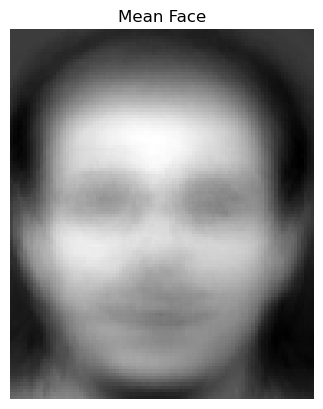

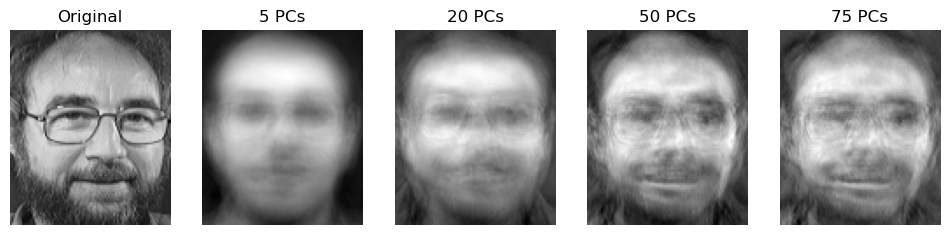

PCA Components = 10  -> Accuracy = 0.9167
PCA Components = 20  -> Accuracy = 0.9333
PCA Components = 30  -> Accuracy = 0.9333
PCA Components = 40  -> Accuracy = 0.9500
PCA Components = 50  -> Accuracy = 0.9500
PCA Components = 75  -> Accuracy = 0.9500


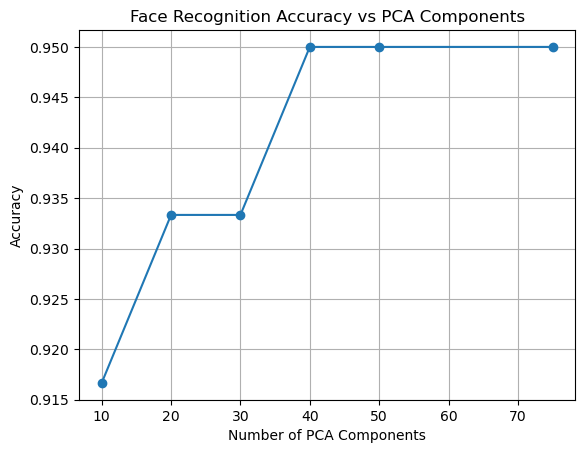


Runtime Comparison
-----------------------
PCA using EVD : 116.99351811408997 seconds
PCA using SVD : 0.38944315910339355 seconds


In [2]:

# FACE RECOGNITION USING PCA (AT&T Dataset)
import os
import time
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
#DATASET LOADING
def load_dataset(dataset_path):
    images = []
    labels = []
    for person in os.listdir(dataset_path):
        if person.startswith("s"):
            label = int(person[1:])
            person_folder = os.path.join(dataset_path, person)
            for img_name in os.listdir(person_folder):
                img_path = os.path.join(person_folder, img_name)
                img = Image.open(img_path).convert("L")  # grayscale
                img = np.array(img, dtype='float64')
                images.append(img.flatten())
                labels.append(label)
    images = np.array(images)
    labels = np.array(labels)
    print("Dataset loaded successfully")
    print("Total images:", images.shape[0])
    print("Image vector size:", images.shape[1])
    return images, labels
#PCA USING EIGENVALUE DECOMPOSITION
def pca_evd(X, k):
    mean_face = np.mean(X, axis=0)
    X_centered = X - mean_face
    cov_matrix = np.cov(X_centered, rowvar=False)
# Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# Sort in descending order
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
# Select top k eigenfaces
    eigenfaces = eigenvectors[:, :k]
    return mean_face, eigenfaces
#PCA USING SVD
def pca_svd(X, k):
    mean_face = np.mean(X, axis=0)
    X_centered = X - mean_face
# Singular Value Decomposition
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    eigenfaces = Vt[:k].T
    return mean_face, eigenfaces
#PROJECTION
def project(X, mean_face, eigenfaces):
    X_centered = X - mean_face
    projected = np.dot(X_centered, eigenfaces)
    return projected
#RECONSTRUCTION
def reconstruct(projected, mean_face, eigenfaces):
    reconstructed = np.dot(projected, eigenfaces.T) + mean_face
    return reconstructed
#VISUALIZATION
def visualize_reconstruction(image, mean_face, eigenfaces_list, img_shape):
    plt.figure(figsize=(12,4))
# Original image
    plt.subplot(1, len(eigenfaces_list)+1, 1)
    plt.imshow(image.reshape(img_shape), cmap='gray')
    plt.title("Original")
    plt.axis("off")
# Reconstructed images
    for i, k in enumerate(eigenfaces_list):
        mean, eigenfaces = pca_evd(X_train, k)
        proj = project(image.reshape(1,-1), mean, eigenfaces)
        rec = reconstruct(proj, mean, eigenfaces)
        plt.subplot(1, len(eigenfaces_list)+1, i+2)
        plt.imshow(rec.reshape(img_shape), cmap='gray')
        plt.title(f"{k} PCs")
        plt.axis("off")
    plt.show()
def show_mean_face(mean_face, img_shape):
    plt.figure()
    plt.imshow(mean_face.reshape(img_shape), cmap='gray')
    plt.title("Mean Face")
    plt.axis("off")
    plt.show()
#FACE RECOGNITION USING SVM
def svm_classification(X_train, X_test, y_train, y_test, components_list):
    accuracies = []
    for k in components_list:
        mean_face, eigenfaces = pca_evd(X_train, k)
        train_proj = project(X_train, mean_face, eigenfaces)
        test_proj = project(X_test, mean_face, eigenfaces)
        clf = SVC(kernel='linear')
        clf.fit(train_proj, y_train)
        preds = clf.predict(test_proj)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        print(f"PCA Components = {k}  -> Accuracy = {acc:.4f}")
    return accuracies
#ACCURACY PLOT
def plot_accuracy(components, accuracies):
    plt.figure()
    plt.plot(components, accuracies, marker='o')
    plt.xlabel("Number of PCA Components")
    plt.ylabel("Accuracy")
    plt.title("Face Recognition Accuracy vs PCA Components")
    plt.grid()
    plt.show()
#MAIN PROGRAM
if __name__ == "__main__":
    dataset_path = "ATnT/ATnT"
    images, labels = load_dataset(dataset_path)
    img_shape = (112,92)  # ORL image size
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels, test_size=0.3, random_state=42
    )
    print("\nTraining size:", X_train.shape)
    print("Testing size:", X_test.shape)
# PCA EVD Runtime
    start = time.time()
    mean_face_evd, eigenfaces_evd = pca_evd(X_train, 50)
    evd_time = time.time() - start
    print("\nEVD PCA runtime:", evd_time)
# PCA SVD Runtime
    start = time.time()
    mean_face_svd, eigenfaces_svd = pca_svd(X_train, 50)
    svd_time = time.time() - start
    print("SVD PCA runtime:", svd_time)
# Mean face visualization 
    show_mean_face(mean_face_evd, img_shape)
# Reconstruction visualization
    sample_image = X_test[0]
    visualize_reconstruction(sample_image, mean_face_evd, [5,20,50,75], img_shape)
# SVM Face Recognition
    components = [10,20,30,40,50,75]
    accuracies = svm_classification(
        X_train, X_test, y_train, y_test, components
    )
# Plot accuracy
    plot_accuracy(components, accuracies)
# Runtime Comparison
    print("\nRuntime Comparison")
    print("-----------------------")
    print("PCA using EVD :", evd_time, "seconds")
    print("PCA using SVD :", svd_time, "seconds")